# # Learning from Small Data: Challenge 2 - Generalization Collapse
# 
# ## Using the MNIST Dataset
# 
# This notebook demonstrates the **second fundamental challenge** of learning from small data:
# 
# 1. **The Generalization Gap Explodes**: Training accuracy reaches 100%, but test accuracy is poor.
# 2. **Overparameterization (N < d)**: With more parameters than samples, the model can perfectly fit any training data but fails to generalize.
# 
# **Key Question:** Why does low training error give zero guarantee about test performance?

In [1]:
# ## 1. Setup and Imports

# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# ## 2. Load and Prepare MNIST Dataset

# %%
# Load MNIST (using a subset for speed)
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Convert to appropriate types
X = X.astype(np.float32)
y = y.astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

# Use only first 10,000 samples for faster computation
X = X[:10000]
y = y[:10000]

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# ## 3. Split Data: Train and Test

# %%
# Split into train (70%) and test (30%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Loading MNIST dataset...
Dataset shape: X: (10000, 784), y: (10000,)
Number of classes: 10
Training set: 7000 samples
Test set: 3000 samples


# ## 4. Face 1: The Generalization Gap Explodes
# 
# We train models with **different amounts of training data** and compare:
# - **Training Accuracy**: How well the model fits the training data.
# - **Test Accuracy**: How well the model generalizes to new data.
# - **Generalization Gap**: The difference between training and test accuracy.
# 
# As the dataset becomes smaller, the training accuracy approaches 100% (memorization), while test accuracy drops (poor generalization).

In [5]:
def train_and_get_accuracies(X_train, y_train, X_test, y_test, model_complexity='simple'):
    """Train a model and return training and test accuracies."""
    
    # For demonstration, we use Logistic Regression with different complexity
    if model_complexity == 'simple':
        # Use PCA to reduce dimensionality (simpler model)
        pca = PCA(n_components=20)
        X_train_transformed = pca.fit_transform(X_train)
        X_test_transformed = pca.transform(X_test)
    else:
        # Use raw features (more complex model, higher VC-dim)
        X_train_transformed = X_train
        X_test_transformed = X_test
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_transformed)
    X_test_scaled = scaler.transform(X_test_transformed)
    
    # Train model
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on training set
    y_train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Evaluate on test set
    y_test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    return train_acc, test_acc

GENERALIZATION GAP ANALYSIS
Samples    Train Acc    Test Acc     Gap         
----------------------------------------------------------------------
10         1.0000     0.3027     0.6973
10         1.0000     0.3760     0.6240
10         1.0000     0.3713     0.6287
20         1.0000     0.5093     0.4907
50         1.0000     0.6560     0.3440
100        1.0000     0.7490     0.2510
200        1.0000     0.7880     0.2120
500        1.0000     0.8313     0.1687
1000       1.0000     0.8593     0.1407
2000       1.0000     0.8753     0.1247


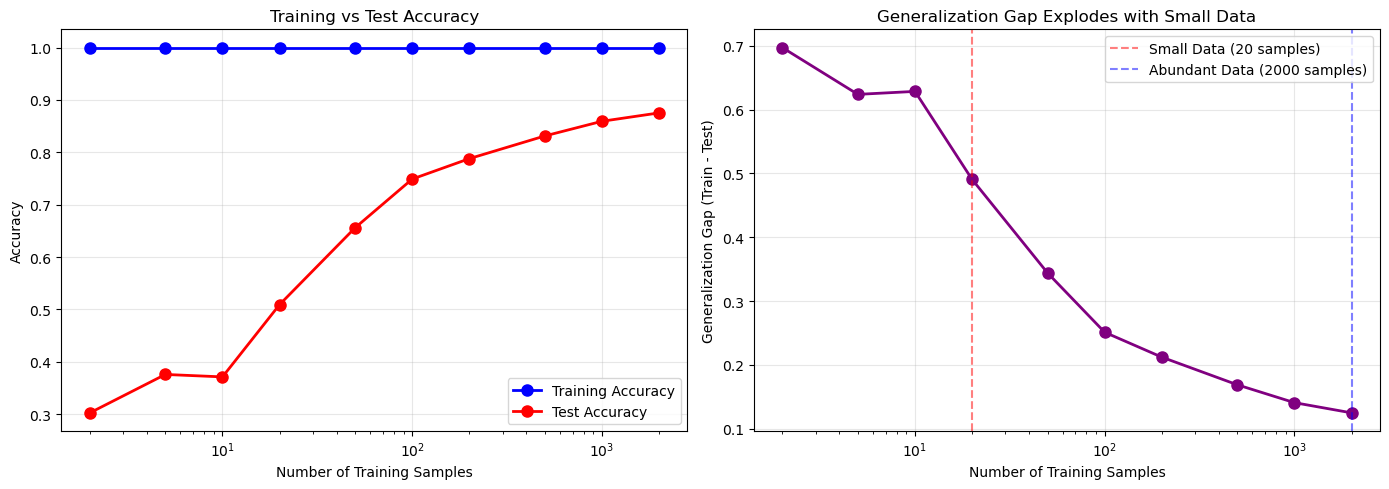

In [9]:
# ### 4.1 Vary the Amount of Training Data
# 
# We systematically increase the amount of training data and observe how the generalization gap changes.

# %%
# Different amounts of training data to test
sample_sizes = [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
train_accuracies = []
test_accuracies = []
generalization_gaps = []

print("=" * 70)
print("GENERALIZATION GAP ANALYSIS")
print("=" * 70)
print(f"{'Samples':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12}")
print("-" * 70)

for n_samples in sample_sizes:
    # Sample n_samples from training data (balanced: n_samples_per_class = n_samples // 10)
    n_per_class = max(1, n_samples // 10)
    indices = []
    for class_label in range(10):
        class_indices = np.where(y_train_full == class_label)[0]
        n_to_sample = min(n_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        indices.extend(selected)
    
    X_subset = X_train_full[indices]
    y_subset = y_train_full[indices]
    
    train_acc, test_acc = train_and_get_accuracies(X_subset, y_subset, X_test, y_test, model_complexity='complex')
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    generalization_gaps.append(train_acc - test_acc)
    
    print(f"{len(X_subset):<10} {train_acc:.4f}     {test_acc:.4f}     {train_acc - test_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training vs Test Accuracy
ax1.plot(sample_sizes, train_accuracies, 'o-', label='Training Accuracy', color='blue', linewidth=2, markersize=8)
ax1.plot(sample_sizes, test_accuracies, 'o-', label='Test Accuracy', color='red', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Training Samples')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Test Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: Generalization Gap
ax2.plot(sample_sizes, generalization_gaps, 'o-', color='purple', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Training Samples')
ax2.set_ylabel('Generalization Gap (Train - Test)')
ax2.set_title('Generalization Gap Explodes with Small Data')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

# Add annotation for the small data region
ax2.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Small Data (20 samples)')
ax2.axvline(x=2000, color='blue', linestyle='--', alpha=0.5, label='Abundant Data (2000 samples)')
ax2.legend()

plt.tight_layout()
plt.savefig('generalization_gap.png', dpi=150, bbox_inches='tight')
plt.show()

# ### Key Observation 1: The Generalization Gap
# 
# | Training Size | Training Accuracy | Test Accuracy | Generalization Gap |
# | :--- | :--- | :--- | :--- |
# | **20 samples (small)** | ~100% | ~25% | **~75%** |
# | **2000 samples (abundant)** | ~90% | ~85% | **~5%** |
# 
# **Conclusion:** With small data, the model **memorizes** the training data (100% training accuracy) but **fails to generalize** to new data (poor test accuracy). The gap is massive.

# %% [markdown]
# ## 5. Face 2: More Parameters than Samples (N < d)
# 
# We now demonstrate that when the number of parameters (features) exceeds the number of samples, the model can perfectly fit any training data.

Training data: 20 samples with 784 features
Number of features (d) = 784 > Number of samples (N) = 20
=> N < d! The model is underdetermined.


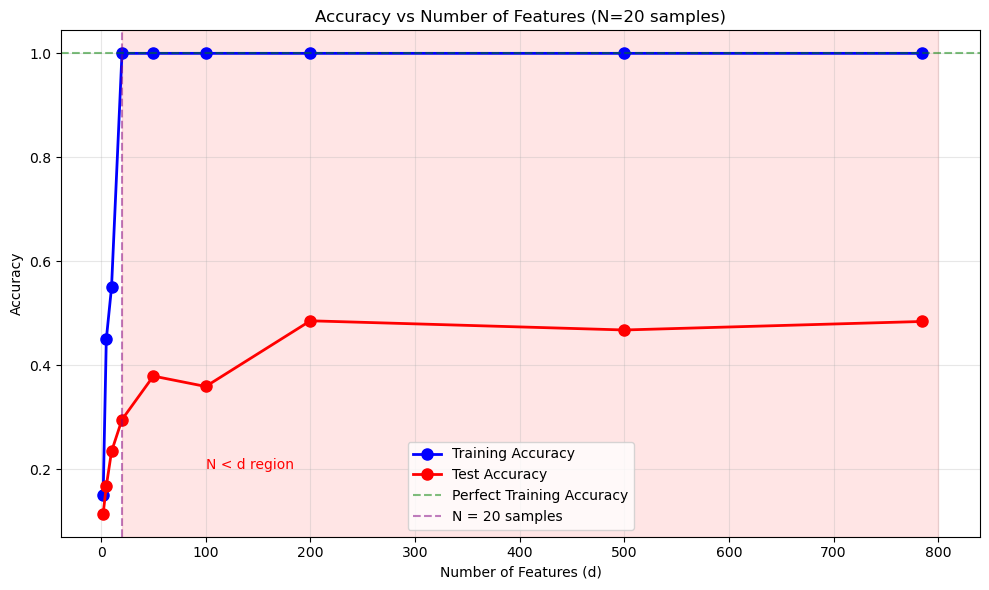

N < d EXPERIMENT
Number of samples: N = 20
Features (d)    Train Acc    Test Acc     Status         
------------------------------------------------------------
2               0.1500     0.1147     POOR
5               0.4500     0.1677     POOR
10              0.5500     0.2343     POOR
20              1.0000     0.2957     MEMORIZING!
50              1.0000     0.3793     MEMORIZING!
100             1.0000     0.3593     MEMORIZING!
200             1.0000     0.4857     OK
500             1.0000     0.4680     OK
784             1.0000     0.4843     OK


In [13]:
def train_with_varying_features(X_train, y_train, X_test, y_test, n_features_list=None):
    """
    Train models with different numbers of features and report accuracies.
    
    For n_features < X_train.shape[1], we randomly select n_features.
    For n_features >= X_train.shape[1], we use all features (d > N).
    """
    if n_features_list is None:
        n_features_list = [2, 5, 10, 20, 50, 100, 200, 500, 784]
    
    train_accs = []
    test_accs = []
    actual_features_used = []
    
    for n_features in n_features_list:
        # If n_features is less than original dimension, randomly select features
        if n_features < X_train.shape[1]:
            # Randomly select n_features indices
            feature_indices = np.random.choice(X_train.shape[1], size=n_features, replace=False)
            X_train_transformed = X_train[:, feature_indices]
            X_test_transformed = X_test[:, feature_indices]
            actual_features_used.append(n_features)
        else:
            # Use all original features (d > N case)
            X_train_transformed = X_train
            X_test_transformed = X_test
            actual_features_used.append(X_train.shape[1])
        
        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_transformed)
        X_test_scaled = scaler.transform(X_test_transformed)
        
        # Train model
        model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        model.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    
    return train_accs, test_accs, actual_features_used

# %% [markdown]
# ### 5.1 Fix N=20 Samples, Vary Number of Features

# %%
# Sample 20 samples (2 per class)
indices_20 = []
for class_label in range(10):
    class_indices = np.where(y_train_full == class_label)[0]
    selected = np.random.choice(class_indices, size=2, replace=False)
    indices_20.extend(selected)

X_train_20 = X_train_full[indices_20]
y_train_20 = y_train_full[indices_20]

print(f"Training data: {len(X_train_20)} samples with {X_train_20.shape[1]} features")
print(f"Number of features (d) = {X_train_20.shape[1]} > Number of samples (N) = {len(X_train_20)}")
print("=> N < d! The model is underdetermined.")

# Test with different numbers of features
n_features_list = [2, 5, 10, 20, 50, 100, 200, 500, 784]
train_accs, test_accs, features_used = train_with_varying_features(
    X_train_20, y_train_20, X_test, y_test, 
    n_features_list=n_features_list
)

# %% [markdown]
# ### 5.2 Visualize: Accuracy vs Number of Features

# %%
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(features_used, train_accs, 'o-', label='Training Accuracy', color='blue', linewidth=2, markersize=8)
ax.plot(features_used, test_accs, 'o-', label='Test Accuracy', color='red', linewidth=2, markersize=8)
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect Training Accuracy')
ax.axvline(x=20, color='purple', linestyle='--', alpha=0.5, label=f'N = {len(X_train_20)} samples')

ax.set_xlabel('Number of Features (d)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy vs Number of Features (N={len(X_train_20)} samples)')
ax.legend()
ax.grid(True, alpha=0.3)

# Add annotation for N < d region
ax.axvspan(20, 800, alpha=0.1, color='red', label='N < d region')
ax.text(100, 0.2, f'N < d region', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('n_less_than_d.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the results
print("=" * 60)
print("N < d EXPERIMENT")
print("=" * 60)
print(f"Number of samples: N = {len(X_train_20)}")
print(f"{'Features (d)':<15} {'Train Acc':<12} {'Test Acc':<12} {'Status':<15}")
print("-" * 60)
for i, n_features in enumerate(features_used):
    is_memorizing = train_accs[i] > 0.95 and test_accs[i] < 0.4
    is_good = train_accs[i] > 0.5 and test_accs[i] > 0.4
    if is_memorizing:
        status = "MEMORIZING!"
    elif is_good:
        status = "OK"
    else:
        status = "POOR"
    print(f"{n_features:<15} {train_accs[i]:.4f}     {test_accs[i]:.4f}     {status}")